In [19]:
import re
import sys
from pathlib import Path

import numpy as np
import torch
from eval_utils import (
    Assignment,
    SingleShardAssignedValLoader,
    load_eval_model_from_checkpoint,
    token_counts_at_examples,
)
import json
from matplotlib import pyplot as plt
from collections import defaultdict
from tqdm.auto import tqdm


In [20]:
sys.path.append("..")

In [21]:
EXPERIMENT_GROUP_DIR = Path(
    "../out/translation-compression/small-multi-domain-prototypes"
)

In [22]:
print(*[str(p.name) for p in EXPERIMENT_GROUP_DIR.glob("*")], sep="\n")

2025-09-23T22-25-46Z__4-domain-translations-fineweb-1-32-prototype__71f5df5c__s64__8000b93__d8bec018
2025-09-24T01-01-20Z__4-domain-translations-fineweb-1-32-prototype__5be2155c__s64__8000b93__7ffd67e5
2025-09-23T03-14-38Z__4-domain-translations-fineweb-4-256-prototype__b1292f0f__s64__8000b93__0e0b06d5
2025-09-23T05-17-10Z__1-domain-fineweb-1-32-prototype__ae5a753e__s64__8000b93__5df3ea37
2025-09-23T03-14-51Z__4-domain-fineweb-4-256-prototype__efb670b8__s64__8000b93__e713fa59
2025-09-23T22-13-36Z__4-domain-fineweb-4-256-prototype__6c9da40f__s64__8000b93__2e070184
2025-09-22T19-20-36Z__4-domain-fineweb-4-256-prototype__be219346__s64__8000b93__0124b75a
2025-09-23T05-16-44Z__4-domain-fineweb-1-32-prototype__aa99d383__s64__8000b93__f0f08992
2025-09-23T22-13-46Z__1-domain-fineweb-4-256-prototype__95f7debd__s64__8000b93__5be70fce
2025-09-23T22-25-47Z__1-domain-fineweb-1-32-prototype__79d1e042__s64__8000b93__ef2a2cdf
2025-09-24T01-01-35Z__4-domain-fineweb-1-32-prototype__1a2aef4e__s64__8000b9

In [23]:
checkpoints_of_interest = set(
    [
        500,
        1_000,
        2_500,
        5_000,
        7_500,
        10_000,
        15_000,
        50_000,
        75_000,
        100_000,
        125_000,
        500_000,
        750_000,
        1_000_000,
    ]
)

In [24]:
experiment = "2025-09-22T19-20-35Z__4-domain-translations-fineweb-4-256-prototype__9ff9dd36__s64__8000b93__974857a0"

In [25]:
experiment_dir = EXPERIMENT_GROUP_DIR / experiment
checkpoint_dir = experiment_dir / "checkpoints"

In [26]:
# Match the pattern step-\d+ to get a list of step numbers
step_numbers = sorted(
    [
        int(match.group(1))
        for p in checkpoint_dir.glob("*")
        if (match := re.search(r"step-(\d+)", str(p.name))) is not None
        # and int(match.group(1)) in checkpoints_of_interest
    ]
)

In [27]:
selected_checkpoint_number = step_numbers[-1]
selected_checkpoint_number

49000

In [28]:
step_dir = checkpoint_dir / f"step-{selected_checkpoint_number:06d}"

In [29]:
device = "cuda:7"

In [30]:
def assignment_from_weight(pair):
    name, weight = pair
    try:
        name = int(name)
        return Assignment(kind=0, src=name), f"compartment_{name}"
    except ValueError:
        pass
    src, dst = name.split(">")
    return Assignment(kind=1, src=int(src), dst=int(dst)), f"translation_{src}_to_{dst}"

In [31]:
experiments = [
    # # 4-256
    # "2025-09-23T03-14-38Z__4-domain-translations-fineweb-4-256-prototype__b1292f0f__s64__8000b93__0e0b06d5",
    # "2025-09-23T03-14-51Z__4-domain-fineweb-4-256-prototype__efb670b8__s64__8000b93__e713fa59",
    # "2025-09-23T03-14-53Z__1-domain-fineweb-4-256-prototype__815f7283__s64__8000b93__66ba2b05"
    # # 1-32
    # "2025-09-23T05-16-44Z__4-domain-fineweb-1-32-prototype__aa99d383__s64__8000b93__f0f08992",
    # "2025-09-23T05-16-56Z__4-domain-translations-fineweb-1-32-prototype__9d1f067b__s64__8000b93__2face835",
    # "2025-09-23T05-17-10Z__1-domain-fineweb-1-32-prototype__ae5a753e__s64__8000b93__5df3ea37",
    # # 1-32 permut
    # "2025-09-23T22-31-15Z__1-domain-fineweb-1-32-prototype__fd443f3d__s64__8000b93__788d2456",
    # "2025-09-23T22-31-15Z__4-domain-translations-fineweb-1-32-prototype__3f3c25f8__s64__8000b93__8c8bb8b9",
    # "2025-09-23T22-31-16Z__4-domain-fineweb-1-32-prototype__25ec38ad__s64__8000b93__9a9b3033",
    # 4-256 permut
    "2025-09-23T22-10-22Z__4-domain-translations-fineweb-4-256-prototype__2efdfae0__s64__8000b93__af78745c",
    "2025-09-23T22-13-36Z__4-domain-fineweb-4-256-prototype__6c9da40f__s64__8000b93__2e070184",
    "2025-09-23T22-13-46Z__1-domain-fineweb-4-256-prototype__95f7debd__s64__8000b93__5be70fce",
]

In [32]:
# Load metrics so far so we can skip them. This will look like a dictionary:
# { "name": { "checkpoints": [500, 1000], "metrics": { "name": [loss1, loss2, ...] } } }


In [33]:
checkpoints_of_interest = set(np.unique(np.floor(np.logspace(3, 6, 50) / 500) * 500).astype(int).tolist())
list(sorted(checkpoints_of_interest))[:50]


[1000,
 1500,
 2000,
 2500,
 3000,
 3500,
 4000,
 4500,
 5000,
 6000,
 7000,
 8000,
 9500,
 10500,
 12500,
 14500,
 16500,
 19000,
 22000,
 25500,
 29000,
 33500,
 39000,
 44500,
 51500,
 59500,
 68500,
 79000,
 91000,
 104500,
 120500,
 138500,
 159500,
 184000,
 212000,
 244000,
 281000,
 323500,
 372500,
 429000,
 494000,
 568500,
 655000,
 754000,
 868500,
 1000000]

In [34]:
if not Path("fineweb_val_metrics.json").exists():
    with open("fineweb_val_metrics.json", "w") as f:
        json.dump({}, f)

with open("fineweb_val_metrics.json", "r") as f:
    fineweb_val_metrics = json.load(f)

for experiment in experiments:
    experiment_dir = EXPERIMENT_GROUP_DIR / experiment
    checkpoint_dir = experiment_dir / "checkpoints"

    metrics = defaultdict(
        list, fineweb_val_metrics.get(experiment, {}).get("metrics", {})
    )
    checkpoints = set(fineweb_val_metrics.get(experiment, {}).get("checkpoints", []))

    step_numbers = sorted(
        [
            int(match.group(1))
            for p in checkpoint_dir.glob("*")
            if (match := re.search(r"step-(\d+)", str(p.name))) is not None
            and int(match.group(1)) in checkpoints_of_interest
        ]
    )

    new_step_numbers = sorted(list(set(step_numbers) - checkpoints))

    print(new_step_numbers)

    step_dir = checkpoint_dir / f"step-{step_numbers[0]:06d}"
    eval_model, config = load_eval_model_from_checkpoint(
        step_dir, experiment_dir, device
    )

    permutations_path = experiment_dir / "permutations.npy"
    has_permutations = permutations_path.exists()

    token_counts = [
        item.tokens_per_compartment
        for item in token_counts_at_examples(
            experiment_dir / "assignments.bin",
            [2048 * i for i in step_numbers],
            T=64,
            expected_num_compartments=config.experiment.max_compartments,
        )
    ]

    for step_number in tqdm(new_step_numbers):
        checkpoints.add(step_number)

        step_dir = checkpoint_dir / f"step-{step_number:06d}"
        eval_model, config = load_eval_model_from_checkpoint(
            step_dir, experiment_dir, device
        )
        with torch.inference_mode():
            for pair in tqdm(config.experiment.weights.items(), unit="metric"):
                torch.random.manual_seed(1024)
                assignment, name = assignment_from_weight(pair)

                val_loader = SingleShardAssignedValLoader(
                    "../data/fineweb350B-dedup/fineweb_val_000000.bin",
                    B=32,
                    T=64,
                    base_vocab_size=50257,
                    max_compartments=4,
                    assignment=assignment,
                    device=device,
                    permute_tokens=has_permutations,
                    permutations_path=str(permutations_path),
                )
                x, y, cids = val_loader.next_batch()
                logits, loss = eval_model(x, y, compartment_ids=cids)

                metrics[f"loss_{name}"].append(loss.item())

    fineweb_val_metrics[experiment] = {
        "metrics": dict(metrics),
        "checkpoints": sorted(list(checkpoints)),
        "token_counts": token_counts,
    }

with open("fineweb_val_metrics.json", "w") as f:
    json.dump(fineweb_val_metrics, f, indent=4)

[59500, 68500]
embedding_vocab_size: 50258
number of parameters: 28.90M
[2048000, 3072000, 4096000, 5120000, 6144000, 7168000, 8192000, 9216000, 10240000, 12288000, 14336000, 16384000, 19456000, 21504000, 25600000, 29696000, 33792000, 38912000, 45056000, 52224000, 59392000, 68608000, 79872000, 91136000, 105472000, 121856000, 140288000]


  0%|          | 0/140288000 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

embedding_vocab_size: 50258
number of parameters: 28.90M


  0%|          | 0/16 [00:00<?, ?metric/s]

FileNotFoundError: [Errno 2] No such file or directory: '../data/fineweb350B-dedup/fineweb_val_000000.bin'

In [ ]:
translation_examples = fineweb_val_metrics[
    next(filter(lambda x: "4-domain-translations" in x, experiments))
]
compartment_examples = fineweb_val_metrics[
    next(filter(lambda x: "4-domain" in x, experiments))
]
single_domain_examples = fineweb_val_metrics[
    next(filter(lambda x: "1-domain" in x, experiments))
]


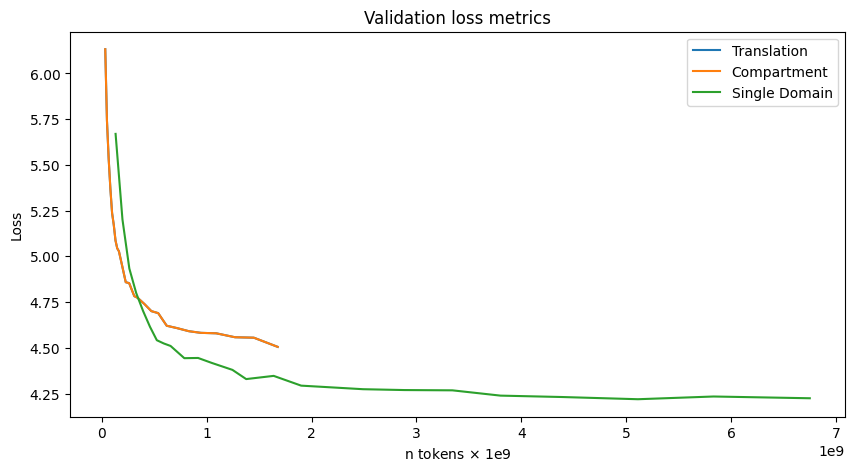

In [ ]:
# Plot the metrics
plt.figure(figsize=(10, 5))
plt.plot(
    np.array(translation_examples["token_counts"])[:, 0],
    # np.array(translation_examples["checkpoints"]),
    np.array(translation_examples["metrics"]["loss_compartment_0"]),
    label="Translation",
)
plt.plot(
    np.array(compartment_examples["token_counts"])[:, 0],
    # np.array(compartment_examples["checkpoints"]),
    np.array(compartment_examples["metrics"]["loss_compartment_0"]),
    label="Compartment",
)
plt.plot(
    np.array(single_domain_examples["token_counts"])[:, 0],
    # np.array(single_domain_examples["checkpoints"]),
    np.array(single_domain_examples["metrics"]["loss_compartment_0"]),
    label="Single Domain",
)
plt.legend()
plt.xlabel(r"n tokens $\times$ 1e9")
plt.ylabel("Loss")
plt.title("Validation loss metrics")
plt.show()
